In [2]:
import numpy as np
from scipy.linalg import expm
from lmfit import Model, Parameters, minimize
import matplotlib.pyplot as plt
# import qcodes as qc
import qutip as qt
import lmfit as lm
from scipy.linalg import expm
import xarray as xr

In [3]:
spin_dim = 7/2
Ix = qt.jmat(spin_dim,'x')
Iy = qt.jmat(spin_dim,'y')
Iz = qt.jmat(spin_dim,'z')
Iz2 = Iz*Iz
Ix2 = Ix*Ix

# Electron spin-1/2 operators (2x2 matrices)
Sx = qt.jmat(1/2, 'x')
Sy = qt.jmat(1/2, 'y')
Sz = qt.jmat(1/2, 'z')

In [4]:
Vxx = 2
Vyy = -1
Vzz = -1
Vxy = -3
Vyz = 3
Vxz = -0.5


V_ab = np.array([[Vxx, Vxy, Vxz], [Vxy, Vyy, Vyz], [Vxz, Vyz, Vzz]])*1e19
I_vec = [Ix, Iy, Iz]
q_n = -0.69e-28
e = 1.6e-19
h = 6.626e-34
I = 7/2
Q_ab = e*q_n*V_ab/(2*I*(2*I-1))/h

In [5]:
H_quad = 0
for alpha in [0, 1, 2]:
    for beta in [0, 1, 2]:
        H_quad += Q_ab[alpha, beta] * I_vec[alpha] * I_vec[beta]
        
H_quad = qt.Qobj(H_quad) / 1e6 # all defined in MHz

In [6]:
H_nuclear = 5.55 * Iz  # Nuclear Zeeman term
H_electron = 28.8e3 * Sz  # Electron Zeeman term

# Construct full Hamiltonian (electron ⊗ nucleus)

H0 = 1.4 * H_nuclear

In [7]:
H_ionized = - H0 + H_quad
(eigenvalues_ionized, eigenstates_ionized) = H_ionized.eigenstates()

eigenstate_ionized_matrix = np.zeros([8,8], dtype=complex)
for i in range(8):
    eigenstate_ionized_matrix[i] = eigenstates_ionized[i].full().flatten()

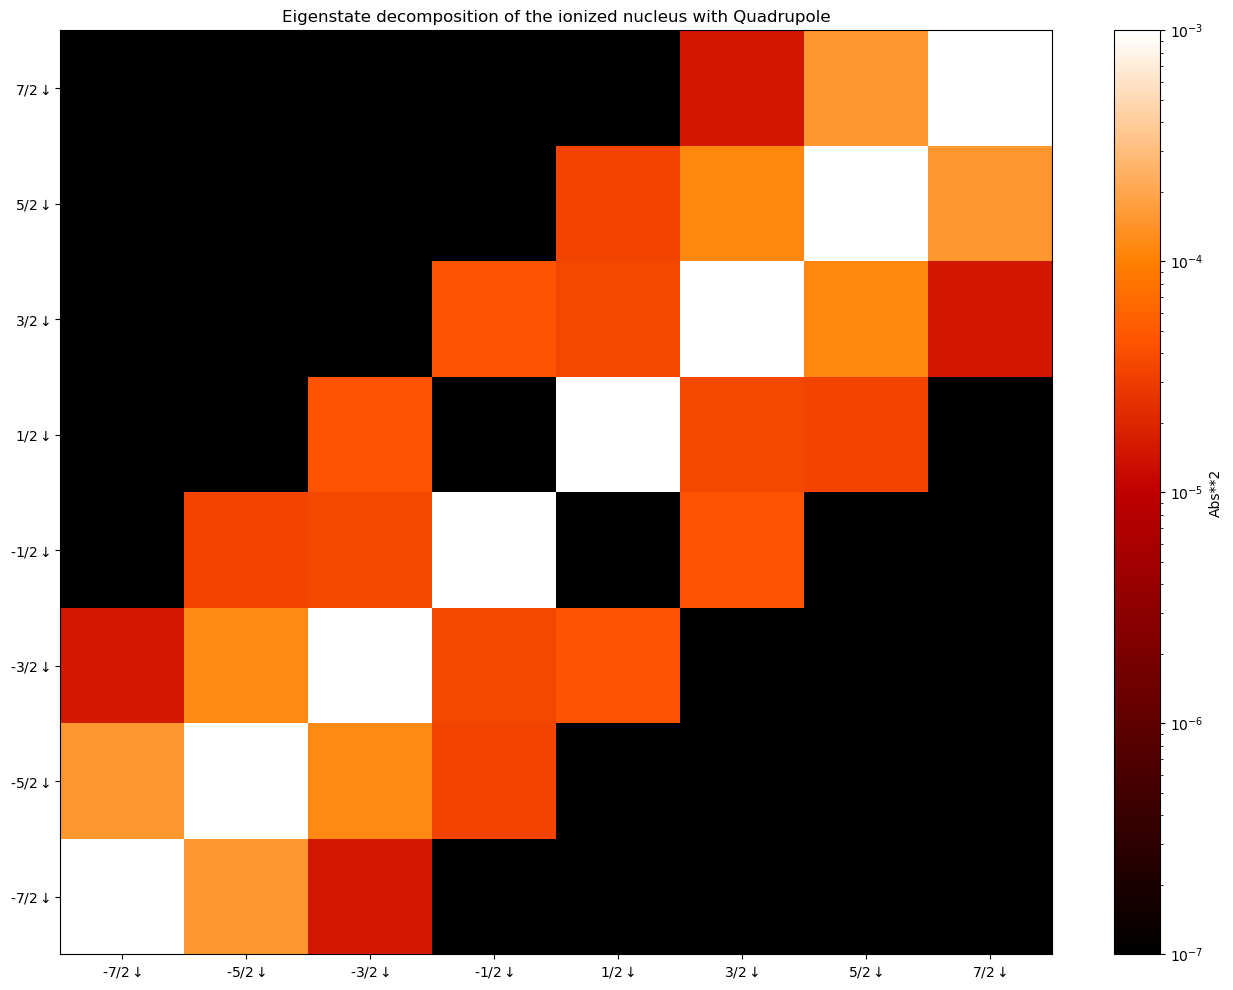

In [8]:
import matplotlib.colors as mcolors
fig, ax = plt.subplots(1,1, figsize=(16,12))
Z = np.abs(eigenstate_ionized_matrix)**2
X, Y = np.arange(8), np.arange(8)
# Plot with pcolormesh using LogNorm
Z[Z==0]=1e-7
pcm = plt.pcolormesh(X, Y, Z, norm=mcolors.LogNorm(vmin=1e-7, vmax=1e-3), cmap="gist_heat")

nucleus_labels = ["-7/2", "-5/2", "-3/2", "-1/2", "1/2", "3/2", "5/2", "7/2"]
electron_labels = [r"$\downarrow$", r"$\uparrow$"]

ax.set_xticks(np.arange(8))
ax.set_yticks(np.arange(8))
ax.set_xticklabels([nucleus_labels[k%8] + electron_labels[(k//8)] for k in range(8)])
ax.set_yticklabels([nucleus_labels[k%8] + electron_labels[(k//8)] for k in range(8)])

ax.set_title('Eigenstate decomposition of the ionized nucleus with Quadrupole')

plt.colorbar(label='Abs**2')

In [9]:
np.diff(np.diff(eigenvalues_ionized))

array([0.01111556, 0.01143041, 0.01174414, 0.01205691, 0.01236892,
       0.01268032])

In [10]:
fq1_measured = 1/1e6 * np.array([-2.266666666666667e+04,-1.968333333333333e+04,-3756,18550,3.176666666666667e+04,2.918333333333333e+04,1.231666666666667e+04,-9050,-22500])
fq2_measured = 1/1e6 * np.array([-700,-820,755,3140,4000,3820,2820,540,-1180])

In [11]:
thetas = np.linspace(0, np.pi, 9)

In [12]:
def calculate_V_matrix(Vxx, Vyy, Vzz, Vxy, Vyz, Vxz):
    V_ab = np.array([[Vxx, Vxy, Vxz], [Vxy, Vyy, Vyz], [Vxz, Vyz, Vzz]])*1e19
    return V_ab

In [13]:
ds24 = xr.load_dataset('analyzed_data_24.nc', engine='h5netcdf')

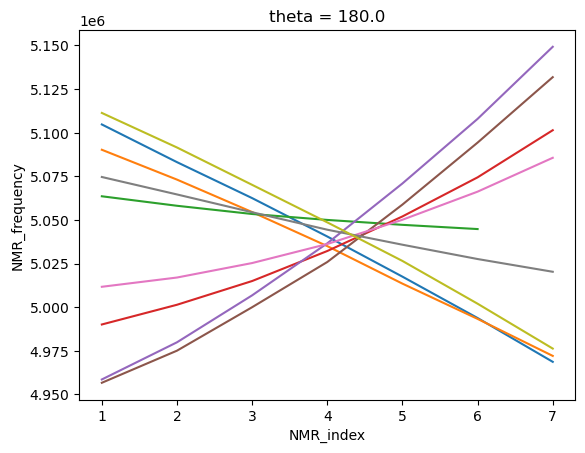

In [14]:
for i in range(len(ds24.theta)):
    ds24.NMR_frequency.isel(theta=i).plot()

In [14]:
ds24['NMR_frequency'] = (('theta', 'NMR_index'), np.array(ds24['NMR_frequency'])[:, ::-1])

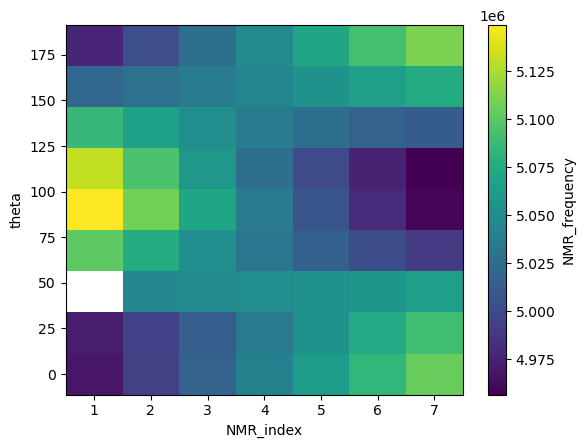

In [15]:
ds24.NMR_frequency.plot()

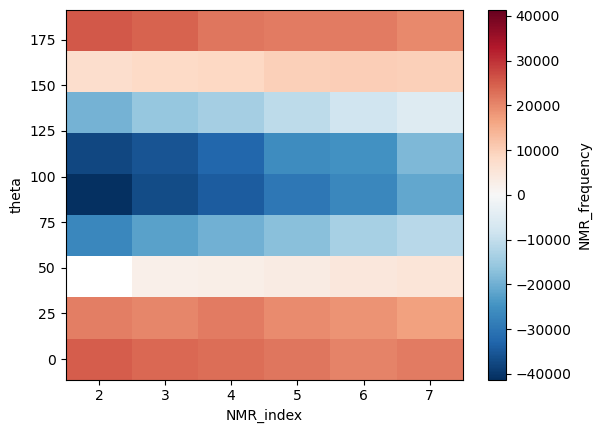

In [16]:
fq1 = ds24['NMR_frequency'].diff(dim='NMR_index')
fq1.plot()

In [17]:
fq1_measured = np.array(fq1.mean(dim='NMR_index'))*1e-6

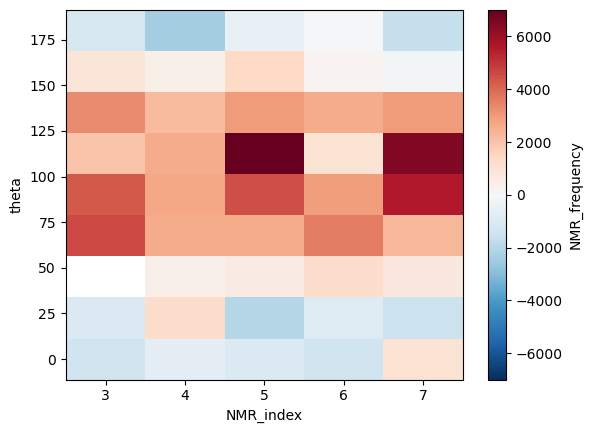

In [18]:
fq2 = ds24['NMR_frequency'].diff(dim='NMR_index').diff(dim='NMR_index')
fq2.plot()

In [19]:
fq2_measured = np.array(fq2.mean(dim='NMR_index'))*1e-6

In [20]:
def calculate_H_quad(Vxx, Vyy, Vzz, Vxy, Vyz, Vxz):
    V_ab = np.array([[Vxx, Vxy, Vxz], [Vxy, Vyy, Vyz], [Vxz, Vyz, Vzz]])*1e19
    I_vec = [Ix, Iy, Iz]
    q_n = -0.69e-28
    e = 1.6e-19
    h = 6.626e-34
    I = 7/2
    Q_ab = e*q_n*V_ab/(2*I*(2*I-1))/h

    H_quad = 0
    for alpha in [0, 1, 2]:
        for beta in [0, 1, 2]:
            H_quad += Q_ab[alpha, beta] * I_vec[alpha] * I_vec[beta]

    H_quad = qt.Qobj(H_quad) / 1e6 # all defined in MHz
    return H_quad

def calculate_ionized_H(theta, Vxx, Vyy, Vzz, Vxy, Vyz, Vxz):
    V_ab = np.array([[Vxx, Vxy, Vxz], [Vxy, Vyy, Vyz], [Vxz, Vyz, Vzz]])*1e19
    I_vec = [Ix, Iy, Iz]
    q_n = -0.69e-28
    e = 1.6e-19
    h = 6.626e-34
    I = 7/2
    Q_ab = e*q_n*V_ab/(2*I*(2*I-1))/h

    H_quad = 0
    for alpha in [0, 1, 2]:
        for beta in [0, 1, 2]:
            H_quad += Q_ab[alpha, beta] * I_vec[alpha] * I_vec[beta]

    H_quad = qt.Qobj(H_quad) / 1e6 # all defined in MHz

    H = - 1 * 5.55 * (Iz * np.cos(theta) + np.sin(theta) * Ix) + H_quad
    return H

def calculate_H_eigenvalues(theta, Vxx, Vyy, Vzz, Vxy, Vyz, Vxz):
    H = calculate_ionized_H(theta, Vxx, Vyy, Vzz, Vxy, Vyz, Vxz)
    (eigenvalues_ionized, eigenstates_ionized) = H.eigenstates()
    return eigenvalues_ionized

def calculate_fq1(eigenvalues):
    return np.mean(np.diff(np.diff(eigenvalues)))

def calculate_fq2(eigenvalues):
    return np.mean(np.diff(np.diff(np.diff(eigenvalues))))

def residual(params):
    Vxx = params['Vxx']
    Vyy = params['Vyy']
    Vzz = params['Vzz']
    Vxy = params['Vxy']
    Vyz = params['Vyz']
    Vxz = params['Vxz']
    
    fq1_array = np.zeros(len(thetas))
    fq2_array = np.zeros(len(thetas))
    
    for t, theta in enumerate(thetas):
        eigenvalues = calculate_H_eigenvalues(theta, Vxx, Vyy, Vzz, Vxy, Vyz, Vxz)
        fq1_array[t] = calculate_fq1(eigenvalues)
        fq2_array[t] = calculate_fq2(eigenvalues)
    
    return np.vstack([(fq1_array - fq1_measured)/np.max(fq1_measured), (fq2_array - fq2_measured)/np.max(fq2_measured)])

# Define initial parameters
params = Parameters()
params.add('Vxx', value=-4, min=-5, max=5)
params.add('Vyy', value=1, min=-5, max=5)
params.add('Vzz', expr='- Vxx - Vyy')
params.add('Vxy', value=0, min=-20, max=20)
params.add('Vyz', value=0, min=-5, max=20)
params.add('Vxz', value=0, min=-5, max=20)

# params.add('Vxx', value=2.5875, min=-5, max=5, vary=False)
# params.add('Vyy', value=-0.6911, min=-5, max=5, vary=False)
# params.add('Vzz', value=-1.8964, min=-5, max=5, vary=False)
# params.add('Vxy', value=7.1687, min=-20, max=20, vary=False)
# params.add('Vyz', value=-1.8842, min=-5, max=20, vary=False)
# params.add('Vxz', value=-0.6428, min=-5, max=20, vary=False)

# Perform minimization
result = minimize(residual, params, method='leastsq')

In [21]:
result.params.values()

dict_values([<Parameter 'Vxx', value=2.6638638047867875 +/- 0.0441, bounds=[-5:5]>, <Parameter 'Vyy', value=-0.7720059875638148 +/- 0.0495, bounds=[-5:5]>, <Parameter 'Vzz', value=-1.8918578172229727 +/- 0.0381, bounds=[-inf:inf], expr='- Vxx - Vyy'>, <Parameter 'Vxy', value=7.682976376137987 +/- 0.0891, bounds=[-20:20]>, <Parameter 'Vyz', value=-1.3001454979293974 +/- 0.114, bounds=[-5:20]>, <Parameter 'Vxz', value=-0.6561053227943434 +/- 0.0365, bounds=[-5:20]>])

In [22]:
params = result.params.valuesdict()
Vxx = params['Vxx']
Vyy = params['Vyy']
Vzz = params['Vzz']
Vxy = params['Vxy']
Vyz = params['Vyz']
Vxz = params['Vxz']
V_ab = np.array([[Vxx, Vxy, Vxz], [Vxy, Vyy, Vyz], [Vxz, Vyz, Vzz]])*1e19

In [23]:
V_ab

array([[ 2.66386380e+19,  7.68297638e+19, -6.56105323e+18],
       [ 7.68297638e+19, -7.72005988e+18, -1.30014550e+19],
       [-6.56105323e+18, -1.30014550e+19, -1.89185782e+19]])

In [24]:
result

In [25]:
fq1_array = np.zeros(len(thetas))
fq2_array = np.zeros(len(thetas))
for t, theta in enumerate(thetas):
    eigenvalues = calculate_H_eigenvalues(theta, **result.params.valuesdict())
    fq1_array[t] = calculate_fq1(eigenvalues)
    fq2_array[t] = calculate_fq2(eigenvalues)

In [26]:
fq1_array

array([ 0.02251054,  0.02008324,  0.00316536, -0.01824414, -0.03163085,
       -0.02922364, -0.01242286,  0.00900669,  0.02251054])

In [27]:
fq2_array

array([-0.00090968, -0.00072959,  0.00104049,  0.00296006,  0.00400196,
        0.00395037,  0.00274647,  0.0006986 , -0.00090968])

In [28]:
fq1_measured

array([ 0.02266667,  0.01968333,  0.003756  , -0.01855   , -0.03176667,
       -0.02918333, -0.01231667,  0.00905   ,  0.0225    ])

In [29]:
fq2_measured

array([-0.0007  , -0.00082 ,  0.000755,  0.00314 ,  0.004   ,  0.00382 ,
        0.00282 ,  0.00054 , -0.00118 ])

In [30]:
ionized_H = calculate_ionized_H(0, **result.params.valuesdict())

In [31]:
ionized_H

Quantum object: dims=[[8], [8]], shape=(8, 8), type='oper', dtype=CSR, isherm=True
Qobj data =
[[-1.93461964e+01+0.j          2.06591376e-02-0.04093837j
  -3.12309144e-02+0.1396714j   0.00000000e+00+0.j
   0.00000000e+00+0.j          0.00000000e+00+0.j
   0.00000000e+00+0.j          0.00000000e+00+0.j        ]
 [ 2.06591376e-02+0.04093837j -1.38637423e+01+0.j
   1.80327736e-02-0.03573394j -4.57173775e-02+0.204458j
   0.00000000e+00+0.j          0.00000000e+00+0.j
   0.00000000e+00+0.j          0.00000000e+00+0.j        ]
 [-3.12309144e-02-0.1396714j   1.80327736e-02+0.03573394j
  -8.35877298e+00+0.j          1.00806269e-02-0.01997588j
  -5.27898804e-02+0.23608776j  0.00000000e+00+0.j
   0.00000000e+00+0.j          0.00000000e+00+0.j        ]
 [ 0.00000000e+00+0.j         -4.57173775e-02-0.204458j
   1.00806269e-02+0.01997588j -2.83128830e+00+0.j
   0.00000000e+00+0.j         -5.27898804e-02+0.23608776j
   0.00000000e+00+0.j          0.00000000e+00+0.j        ]
 [ 0.00000000e+00+0.j    

In [32]:
eigenvalues_ionized

array([-27.15477068, -19.41928095, -11.67267565,  -3.91463994,
         3.8551399 ,  11.63697666,  19.43118233,  27.23806833])

In [33]:
(eigenvalues_ionized, eigenstates_ionized) = ionized_H.eigenstates()

eigenstate_ionized_matrix = np.zeros([8,8], dtype=complex)
for i in range(8):
    eigenstate_ionized_matrix[i] = eigenstates_ionized[i].full().flatten()

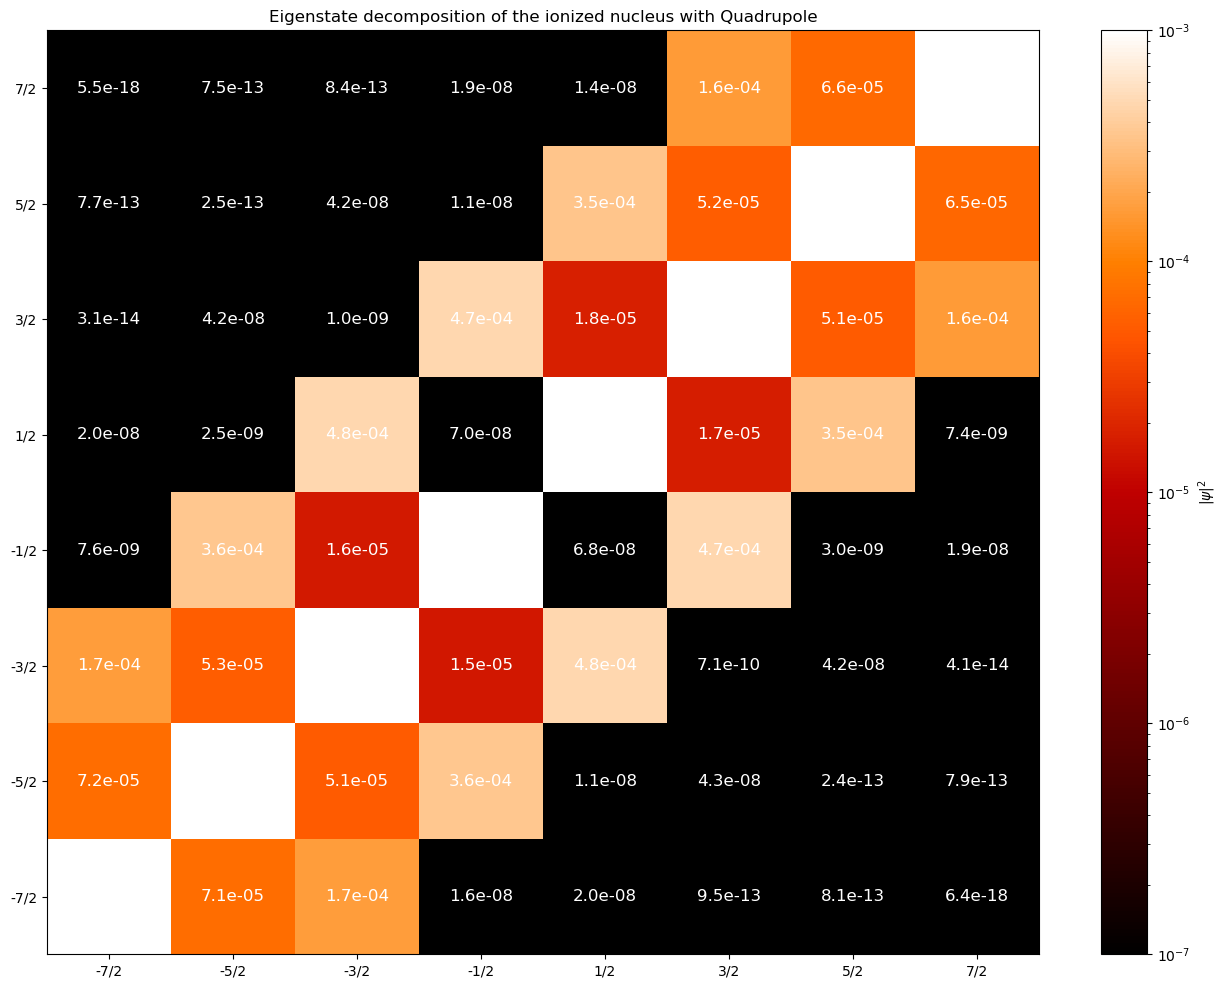

In [34]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

fig, ax = plt.subplots(figsize=(16, 12))
Z = np.abs(eigenstate_ionized_matrix)**2
X, Y = np.arange(8), np.arange(8)

# Ensure no zeros for LogNorm
Z[Z == 0] = 1e-7

# Plot with pcolormesh using LogNorm
pcm = ax.pcolormesh(X, Y, Z, norm=mcolors.LogNorm(vmin=1e-7, vmax=1e-3), cmap="gist_heat")

# Add readable numbers
for i in range(8):
    for j in range(8):
        ax.text(j, i, f"{Z[i, j]:.1e}", color="white", ha="center", va="center", fontsize=12)

nucleus_labels = ["-7/2", "-5/2", "-3/2", "-1/2", "1/2", "3/2", "5/2", "7/2"]
electron_labels = [r"$\downarrow$", r"$\uparrow$"]

ax.set_xticks(np.arange(8))
ax.set_yticks(np.arange(8))
ax.set_xticklabels(nucleus_labels)
ax.set_yticklabels(nucleus_labels)

ax.set_title('Eigenstate decomposition of the ionized nucleus with Quadrupole')

plt.colorbar(pcm, label=r'$|\psi|^2$')
plt.show()


Text(0.5, 0, '$\\theta$')

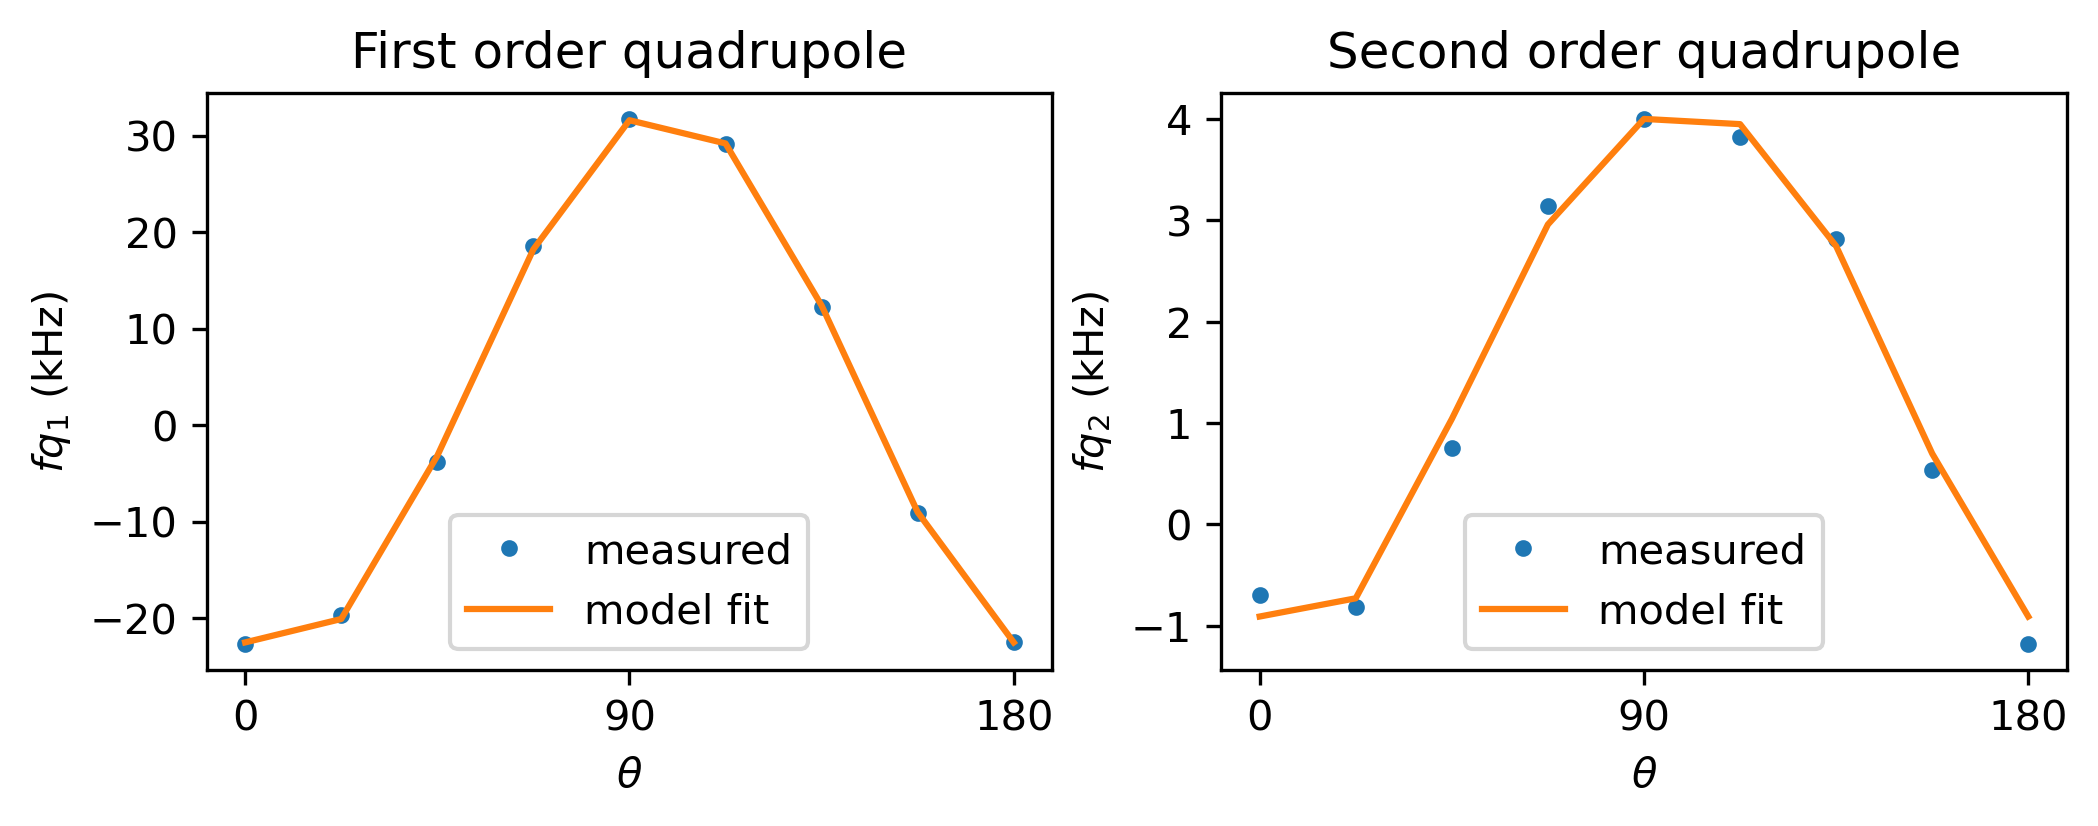

In [35]:
fig, ax = plt.subplots(1,2, figsize=(8,2.5), dpi=300)
ax[0].plot(thetas/np.pi*180, -fq1_measured*1e3, '.', label='measured')
ax[0].plot(thetas/np.pi*180, -fq1_array*1e3, label='model fit')
ax[0].legend()
ax[1].plot(thetas/np.pi*180, fq2_measured*1e3, '.', label='measured')
ax[1].plot(thetas/np.pi*180, fq2_array*1e3, label='model fit')
ax[1].legend()
ax[0].set_title('First order quadrupole')
ax[1].set_title('Second order quadrupole')

ax[0].set_ylabel('$fq_1$ (kHz)')
ax[1].set_ylabel('$fq_2$ (kHz)')

ax[0].set_xticks([0, 90, 180])
ax[1].set_xticks([0, 90, 180])

ax[0].set_xlabel(r'$\theta$')
ax[1].set_xlabel(r'$\theta$')

In [36]:
v_ab = calculate_V_matrix(**result.params.valuesdict())
(eigenvals, eigenstates) = qt.Qobj(v_ab).eigenstates()

In [37]:
eigenstates

array([Quantum object: dims=[[3], [1]], shape=(3, 1), type='ket', dtype=Dense
       Qobj data =
       [[ 0.61280778]
        [-0.781054  ]
        [-0.12008859]]                                                       ,
       Quantum object: dims=[[3], [1]], shape=(3, 1), type='ket', dtype=Dense
       Qobj data =
       [[ 0.16963703]
        [-0.01840151]
        [ 0.9853348 ]]                                                       ,
       Quantum object: dims=[[3], [1]], shape=(3, 1), type='ket', dtype=Dense
       Qobj data =
       [[ 0.7718095]
        [ 0.6241923]
        [-0.1212191]]                                                        ],
      dtype=object)

In [38]:
eigenvals

array([-6.99989845e+19, -1.98053338e+19,  8.98043183e+19])

In [39]:
H_quad = calculate_H_quad(**result.params.valuesdict())

In [40]:
np.save('H_quad_fit.npy', H_quad.full())

In [41]:
H_quad

Quantum object: dims=[[8], [8]], shape=(8, 8), type='oper', dtype=CSR, isherm=True
Qobj data =
[[ 0.07880362+0.j          0.02065914-0.04093837j -0.03123091+0.1396714j
   0.        +0.j          0.        +0.j          0.        +0.j
   0.        +0.j          0.        +0.j        ]
 [ 0.02065914+0.04093837j  0.01125766+0.j          0.01803277-0.03573394j
  -0.04571738+0.204458j    0.        +0.j          0.        +0.j
   0.        +0.j          0.        +0.j        ]
 [-0.03123091-0.1396714j   0.01803277+0.03573394j -0.03377298+0.j
   0.01008063-0.01997588j -0.05278988+0.23608776j  0.        +0.j
   0.        +0.j          0.        +0.j        ]
 [ 0.        +0.j         -0.04571738-0.204458j    0.01008063+0.01997588j
  -0.0562883 +0.j          0.        +0.j         -0.05278988+0.23608776j
   0.        +0.j          0.        +0.j        ]
 [ 0.        +0.j          0.        +0.j         -0.05278988-0.23608776j
   0.        +0.j         -0.0562883 +0.j         -0.01008063+0.0199